# Fraud / Anomaly Detection — Credit Card Transactions

Unsupervised anomaly detection on the Kaggle *Credit Card Fraud Detection* dataset using Isolation Forest.

**Pipeline:** Load → Explore → Clean/Scale → Train → Evaluate → Export model for the Streamlit dashboard.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score
import joblib

pd.set_option('display.max_columns', 50)

## 2. Load the data

Update the path below to wherever you downloaded `creditcard.csv`.

In [2]:
DATA_PATH = "creditcard.csv"  # update if it's somewhere else

df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 3. Explore the data

Check missing values and the class imbalance (fraud is normally under 1% of all transactions).

In [3]:
print("Missing values per column:")
print(df.isnull().sum().sum(), "total missing values")

print("\nClass balance:")
print(df['Class'].value_counts())
print(df['Class'].value_counts(normalize=True) * 100)

Missing values per column:
0 total missing values

Class balance:
Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


Fraud rate: 0.1727%


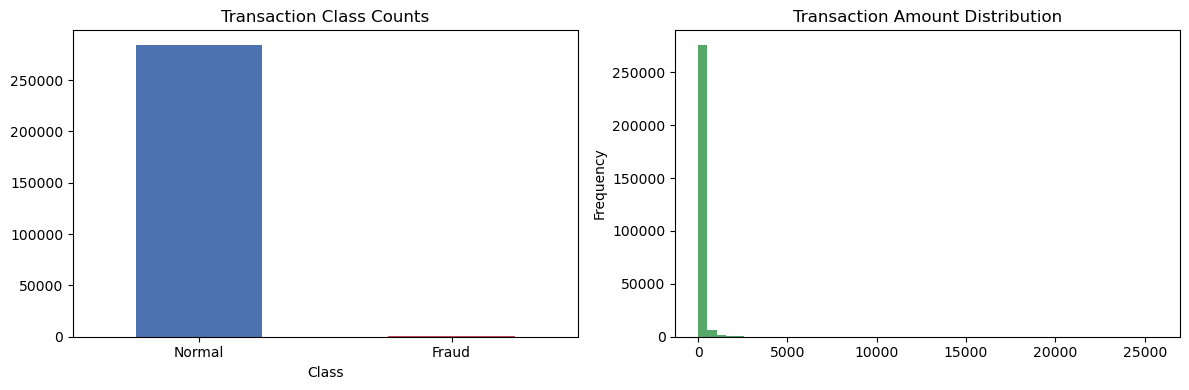

In [4]:
fraud_rate = df['Class'].mean()
print(f"Fraud rate: {fraud_rate:.4%}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df['Class'].value_counts().plot(kind='bar', ax=ax[0], color=['#4C72B0', '#C44E52'])
ax[0].set_title('Transaction Class Counts')
ax[0].set_xticklabels(['Normal', 'Fraud'], rotation=0)

df['Amount'].plot(kind='hist', bins=50, ax=ax[1], color='#55A868')
ax[1].set_title('Transaction Amount Distribution')
plt.tight_layout()
plt.show()

## 4. Clean and scale

The `V1`–`V28` columns are already PCA-transformed by Kaggle. We only need to scale `Amount` and `Time` to match that same range.

In [5]:
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled'] = scaler.fit_transform(df[['Time']])

feature_cols = [c for c in df.columns if c.startswith('V')] + ['Amount_scaled', 'Time_scaled']
X = df[feature_cols]
y = df['Class']  # only used later, for evaluation — NOT used in training

print(f"Features used: {len(feature_cols)}")
X.head()

Features used: 30


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount_scaled,Time_scaled
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.244964,-1.996583
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.342475,-1.996583
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.160686,-1.996562
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.140534,-1.996562
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.073403,-1.996541


## 5. Train an Isolation Forest

Unsupervised model — it never sees the `Class` labels during training. `contamination` is set to roughly match the real fraud rate.

In [6]:
model = IsolationForest(
    n_estimators=200,
    contamination=fraud_rate,   # ~0.0017 for this dataset
    random_state=42,
    n_jobs=-1
)

model.fit(X)

# -1 = anomaly, 1 = normal -> convert to 1 = anomaly, 0 = normal to match the Class column
raw_preds = model.predict(X)
df['predicted_anomaly'] = np.where(raw_preds == -1, 1, 0)
df['anomaly_score'] = model.decision_function(X)  # lower = more anomalous

df[['Class', 'predicted_anomaly', 'anomaly_score']].head()

,Class,predicted_anomaly,anomaly_score
0,0,0,0.270553
1,0,0,0.291007
2,0,0,0.200745
3,0,0,0.248553
4,0,0,0.263752


## 6. Evaluate against the real labels

We only use `Class` here to check how well the unsupervised model did — this is the section to screenshot for your README/portfolio.

In [7]:
print(classification_report(y, df['predicted_anomaly'], target_names=['Normal', 'Fraud']))

cm = confusion_matrix(y, df['predicted_anomaly'])
print("Confusion Matrix:")
print(cm)

precision = precision_score(y, df['predicted_anomaly'])
recall = recall_score(y, df['predicted_anomaly'])
f1 = f1_score(y, df['predicted_anomaly'])
print(f"\nPrecision: {precision:.3f} | Recall: {recall:.3f} | F1: {f1:.3f}")

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    284315
       Fraud       0.26      0.26      0.26       492

    accuracy                           1.00    284807
   macro avg       0.63      0.63      0.63    284807
weighted avg       1.00      1.00      1.00    284807

Confusion Matrix:
[[283949    366]
 [   366    126]]

Precision: 0.256 | Recall: 0.256 | F1: 0.256


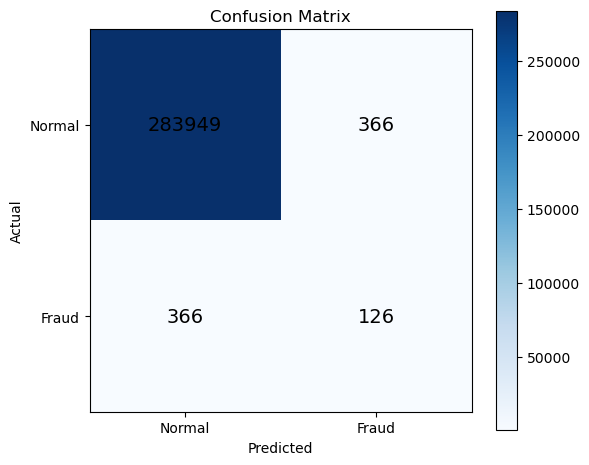

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_xticklabels(['Normal', 'Fraud'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['Normal', 'Fraud'])
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='black', fontsize=14)
plt.colorbar(im)
plt.tight_layout()
plt.show()

## 7. Save the model and scaler

These get loaded by the Streamlit dashboard (`app.py`) so you don't retrain every time.

In [9]:
joblib.dump(model, 'isolation_forest_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

# Also save a sample of scored data for the dashboard to load quickly
df.to_csv('scored_transactions.csv', index=False)

print("Saved: isolation_forest_model.pkl, scaler.pkl, scored_transactions.csv")

Saved: isolation_forest_model.pkl, scaler.pkl, scored_transactions.csv
